## DSC 530 Final Project
## Predicting Consumer Behavior from Sociodemographic Profiles
### Insurance Company Benchmark (COIL 2000) — UCI Machine Learning Repository
**Author:** Kat Chu         
**Course:** DSC 530  
**Dataset Source:** UCI Machine Learning Repository  
**Origin:** Real world data supplied by Sentient Machine Research, a Dutch data mining company  
**Reference:** Van der Putten, P. & Van Someren, M. (2000). CoIL Challenge 2000: The Insurance Company Case.

In [1]:
# ── Data Manipulation ────────────────────────────────────────────────────────
import pandas as pd        # working with dataframes (tables of data)
import numpy as np         # numerical computations and arrays

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt   # base plotting library
import seaborn as sns              # higher-level, prettier visualizations

# ── Statistics ────────────────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, f_oneway, pearsonr

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ── Settings ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print("All libraries loaded successfully.")

All libraries loaded successfully.


## Preliminary Task 1: Dataset Selection

### 1a. Adequacy Check

The dataset selected for this project is the Insurance Company Benchmark (COIL 2000) 
from the UCI Machine Learning Repository.

- **Size:** 5,822 customer records in the training set, 4,000 in the evaluation set, 9,000 total
- **Features:** 86 variables covering sociodemographic profiles, insurance contribution amounts, and policy counts
- **Relevance:** The dataset contains rich demographic and behavioral data that is well suited for 
  classification, clustering, and regression tasks as required by this project

The dataset is large enough and contains sufficient variables to support the full range of 
EDA and machine learning tasks required for this project.

### 1b. Data Integrity

**Source:** The data was supplied by Sentient Machine Research, a Dutch data mining company, 
and is based on a real world business problem. It was used in the CoIL Challenge 2000 
data mining competition, giving it academic credibility.

**Data Collection Methodology:** Sociodemographic variables (columns 1–43) are derived from 
zip codes, meaning all customers in the same zip code area share identical values for those 
attributes. This is important context because it means demographic variables reflect 
neighborhood-level characteristics, not individual-level measurements.

**Potential Biases:**
- Since demographics are zip-code based, individual variation within a neighborhood is not captured
- The dataset reflects Dutch society in 2000, cultural and economic patterns may differ 
  from other regions or time periods
- All variable names are abbreviated codes (e.g. MOSTYPE, MGEMLEEF) that require the 
  data dictionary to interpret correctly

**Variable Name Interpretation:** All column names follow Dutch abbreviations. 
Throughout this project I will reference the data dictionary to ensure variables 
are interpreted in their correct context.

In [3]:
# Loading the dataset
# The file is tab delimited with no header row
# Column names are assigned manually based on the data dictionary (TicDataDescr.txt)

columns = [
    "MOSTYPE", "MAANTHUI", "MGEMOMV", "MGEMLEEF", "MOSHOOFD",
    "MGODRK", "MGODPR", "MGODOV", "MGODGE", "MRELGE",
    "MRELSA", "MRELOV", "MFALLEEN", "MFGEKIND", "MFWEKIND",
    "MOPLHOOG", "MOPLMIDD", "MOPLLAAG", "MBERHOOG", "MBERZELF",
    "MBERBOER", "MBERMIDD", "MBERARBG", "MBERARBO", "MSKA",
    "MSKB1", "MSKB2", "MSKC", "MSKD", "MHHUUR",
    "MHKOOP", "MAUT1", "MAUT2", "MAUT0", "MZFONDS",
    "MZPART", "MINKM30", "MINK3045", "MINK4575", "MINK7512",
    "MINK123M", "MINKGEM", "MKOOPKLA", "PWAPART", "PWABEDR",
    "PWALAND", "PPERSAUT", "PBESAUT", "PMOTSCO", "PVRAAUT",
    "PAANHANG", "PTRACTOR", "PWERKT", "PBROM", "PLEVEN",
    "PPERSONG", "PGEZONG", "PWAOREG", "PBRAND", "PZEILPL",
    "PPLEZIER", "PFIETS", "PINBOED", "PBYSTAND", "AWAPART",
    "AWABEDR", "AWALAND", "APERSAUT", "ABESAUT", "AMOTSCO",
    "AVRAAUT", "AAANHANG", "ATRACTOR", "AWERKT", "ABROM",
    "ALEVEN", "APERSONG", "AGEZONG", "AWAOREG", "ABRAND",
    "AZEILPL", "APLEZIER", "AFIETS", "AINBOED", "ABYSTAND",
    "CARAVAN"
]

df = pd.read_csv("/Users/katchu/Desktop/Masters Data Analytics/DSC 530/customer-segmentation-insurance-ml/data/ticdata2000.txt", sep="\t", header=None, names=columns)

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset loaded successfully.
Shape: 5822 rows x 86 columns


,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,...,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND,CARAVAN
0,33,1,3,2,8,0,5,1,3,7,...,0,0,0,1,0,0,0,0,0,0
1,37,1,2,2,8,1,4,1,4,6,...,0,0,0,1,0,0,0,0,0,0
2,37,1,2,2,8,0,4,2,4,3,...,0,0,0,1,0,0,0,0,0,0
3,9,1,3,3,3,2,3,2,4,5,...,0,0,0,1,0,0,0,0,0,0
4,40,1,4,2,10,1,4,1,4,7,...,0,0,0,1,0,0,0,0,0,0


The dataset loaded successfully with 5,822 rows and 86 columns. Each row represents 
one customer. The column names match the data dictionary from UCI. Notice that all 
values are integers, even sociodemographic variables like age group and social class 
are encoded as numbers, which we will interpret using the data dictionary throughout 
this analysis.

## Preliminary Task 2: Data Cleaning and Preparation

In [4]:
# 2a. Handle Missing Values and Outliers
# Verifying dataset integrity, checking for missing values and duplicates

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Data types:\n{df.dtypes.value_counts()}")

Shape: 5822 rows x 86 columns
Missing values: 0
Duplicate rows: 602
Data types:
int64    86
Name: count, dtype: int64


In [5]:
# Investigating duplicates before deciding how to handle them
# 602 rows were flagged 
# I want to understand why before removing anything

# How many duplicates do we have?
total_rows = len(df)
duplicate_count = df.duplicated().sum()
print(f"Total rows: {total_rows}")
print(f"Duplicate rows: {duplicate_count}")
print(f"That is {duplicate_count/total_rows*100:.1f}% of the dataset")

# Mark ALL copies of duplicates so we can see both sides. 
all_dupes = df[df.duplicated(keep=False)] # keep=False gives us both duplicates, the first and second. 

# Sort them so identical rows appear next to each other
all_dupes_sorted = all_dupes.sort_values(list(df.columns))

# Pick meaningful columns to inspect
# I check the data dictionary for columns that would describe the customer
# MOSTYPE = customer subtype, MGEMLEEF = avg age, MOSHOOFD = main type, MINKGEM = avg income
print("\nExample of duplicate rows side by side:")
print(all_dupes_sorted[["MOSTYPE", "MGEMLEEF", "MOSHOOFD", "MINKGEM"]].head(6))

Total rows: 5822
Duplicate rows: 602
That is 10.3% of the dataset

Example of duplicate rows side by side:
      MOSTYPE  MGEMLEEF  MOSHOOFD  MINKGEM
2058        1         4         1        4
5700        1         4         1        4
3525        1         4         1        4
3943        1         4         1        4
984         1         4         1        6
4572        1         4         1        6


The integrity check confirmed no missing values. However 602 duplicate rows (10.3%) 
were flagged. After investigation this is not a data quality issue. The data dictionary 
confirms that sociodemographic variables are derived from zip codes, so customers in the 
same area naturally share identical profile values. These are real distinct customers 
and no rows will be dropped.

In [6]:
# 2b. Recoding or Encoding of Variables
# All variables are already encoded as integers so no recoding is required.
# However CARAVAN is the only binary variable, all others are ordinal or continuous.
# I will note this for use in the modeling sections.

print("Variable types summary:")
print(f"  All variables are integer encoded: {df.dtypes.value_counts().to_dict()}")
print(f"\nCARAVAN unique values: {sorted(df['CARAVAN'].unique())}")
print(f"  0 = does not own a mobile home policy")
print(f"  1 = owns a mobile home policy")

Variable types summary:
  All variables are integer encoded: {dtype('int64'): 86}

CARAVAN unique values: [0, 1]
  0 = does not own a mobile home policy
  1 = owns a mobile home policy


In [7]:
# 2c. Data Transformation
# Checking skewness of key variables to determine if transformation is needed

key_vars = ["MOSTYPE", "MOSHOOFD", "MGEMLEEF", "MINKGEM",
            "MKOOPKLA", "MHHUUR", "MHKOOP", "MOPLHOOG",
            "MAUT1", "MAUT0", "PPERSAUT", "PBRAND",
            "PLEVEN", "APERSAUT", "ABRAND", "CARAVAN"]

skewness = df[key_vars].skew()
print("Skewness of key variables:")
print(skewness)
print("\nVariables with high skewness (> 1 or < -1):")
print(skewness[abs(skewness) > 1])

Skewness of key variables:
MOSTYPE    -0.435070
MOSHOOFD   -0.331529
MGEMLEEF    0.471976
MINKGEM     0.816473
MKOOPKLA    0.220511
MHHUUR      0.151102
MHKOOP     -0.158237
MOPLHOOG    1.363253
MAUT1      -0.236885
MAUT0       0.728571
PPERSAUT   -0.013085
PBRAND      0.392991
PLEVEN      4.883105
APERSAUT    0.977368
ABRAND      0.750461
CARAVAN     3.714912
dtype: float64

Variables with high skewness (> 1 or < -1):
MOPLHOOG    1.363253
PLEVEN      4.883105
CARAVAN     3.714912
dtype: float64


Three variables show high skewness: MOPLHOOG (high education), PLEVEN (life insurance 
contributions), and CARAVAN (mobile home policy ownership). This is likely driven by 
income and education inequality, higher education and disposable income are not evenly 
distributed across the population, meaning most customers cannot afford life insurance 
or mobile home policies at all. This creates a concentration of values near zero with 
a long tail of higher values, which explains the skew.
Most customers hold zero policies for most product types. Since many of these variables 
are binary or ordinal counts rather than continuous measures, log transformation is not 
appropriate here. The skewness will be noted as a limitation and accounted for when 
selecting models in later sections.

In [8]:
# 2d. Normalization and Standardization
# If we apply machine learning algorithms (clustering, classification)
# standardization is important so that variables with larger ranges don't dominate
# I will create a scaled version of the key variables for use in ML tasks

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale only the key variables identified for analysis
df_scaled = df[key_vars].copy()
df_scaled_array = scaler.fit_transform(df_scaled)
df_scaled = pd.DataFrame(df_scaled_array, columns=key_vars)

print("Standardization applied to key variables.")
print("\nBefore scaling — MINKGEM range:")
print(f"  Min: {df['MINKGEM'].min()}, Max: {df['MINKGEM'].max()}")
print("\nAfter scaling — MINKGEM range:")
print(f"  Min: {df_scaled['MINKGEM'].min():.3f}, Max: {df_scaled['MINKGEM'].max():.3f}")

Standardization applied to key variables.

Before scaling — MINKGEM range:
  Min: 0, Max: 9

After scaling — MINKGEM range:
  Min: -2.872, Max: 3.958


StandardScaler has been applied to the key variables, transforming them to have a 
mean of 0 and standard deviation of 1. The original dataframe df is kept unchanged 
for EDA and visualization. The scaled version df_scaled will be used specifically 
for clustering and classification tasks in the advanced analysis sections.

## EDA Task 1: Variable Characteristics and Summary Statistics

### 1a. Variable Descriptions

With 86 columns it is not practical to analyze every single one in depth. I am 
selecting the most meaningful variables from each group based on the data dictionary.

**Sociodemographic Variables (Who the customer is):**
- MOSTYPE — Customer subtype, 41 categories (e.g. "Lower class large families")
- MOSHOOFD — Customer main type, 10 broader categories
- MGEMLEEF — Average age group in the zip code area (1=20-30, 6=70-80)
- MINKGEM — Average income in the zip code area
- MKOOPKLA — Purchasing power class
- MHHUUR — Percentage of renters in the zip code area
- MHKOOP — Percentage of home owners in the zip code area
- MOPLHOOG — Percentage with high level education
- MAUT1 — Percentage with 1 car
- MAUT0 — Percentage with no car

**Insurance Product Variables (What the customer buys):**
- PPERSAUT — Contribution to car insurance policies
- PBRAND — Contribution to fire insurance policies
- PLEVEN — Contribution to life insurance policies
- APERSAUT — Number of car policies
- ABRAND — Number of fire policies
- CARAVAN — Whether the customer owns a mobile home policy (0 or 1)

**A note on variable names:** All column names in this dataset use abbreviated Dutch codes 
(e.g. MOSTYPE, MGEMLEEF). Rather than renaming all 86 columns, the original names will be 
kept throughout this project to maintain consistency with the source data. The full 
description of each variable will be written alongside its abbreviation whenever referenced 
in the analysis.

## EDA Task 2: Univariate Analysis

### 2a. Descriptive Statistics

In this section I examine each variable individually to understand its distribution 
and characteristics before looking at relationships between variables.

In [9]:
# Descriptive statistics for key variables
# Calculating mean, median, mode, variance, skewness and kurtosis

stats_df = pd.DataFrame({
    "Mean":     df[key_vars].mean(),
    "Median":   df[key_vars].median(),
    "Mode":     df[key_vars].mode().iloc[0],
    "Variance": df[key_vars].var(),
    "Skewness": df[key_vars].skew(),
    "Kurtosis": df[key_vars].kurtosis()
}).round(3)

print("Descriptive Statistics for Key Variables:")
stats_df

Descriptive Statistics for Key Variables:


,Mean,Median,Mode,Variance,Skewness,Kurtosis
MOSTYPE,24.253,30.0,33,165.038,-0.435,-1.352
MOSHOOFD,5.774,7.0,8,8.161,-0.332,-1.345
MGEMLEEF,2.991,3.0,3,0.664,0.472,0.622
MINKGEM,3.784,4.0,3,1.737,0.816,1.444
MKOOPKLA,4.236,4.0,3,4.029,0.221,-0.876
MHHUUR,4.237,4.0,0,9.544,0.151,-1.305
MHKOOP,4.772,5.0,9,9.547,-0.158,-1.305
MOPLHOOG,1.461,1.0,0,2.634,1.363,1.996
MAUT1,6.040,6.0,6,2.411,-0.237,0.622
MAUT0,1.959,2.0,2,2.559,0.729,0.866


The descriptive statistics reveal important patterns across the key variables. 
Sociodemographic variables like MGEMLEEF (average age group) and MAUT1 (percentage 
with 1 car) show low skewness and consistent mean/median values, suggesting relatively 
even distributions across the customer base. In contrast, insurance product variables 
like PLEVEN (life insurance contributions) and CARAVAN (mobile home policy ownership) 
show extreme skewness and high kurtosis, confirming that most customers hold zero of 
these policies with only a small minority owning them. PPERSAUT (car insurance 
contributions) shows a notable gap between its mean (2.97) and median (5.0), 
indicating that non-contributors pull the average down significantly.

### 2b. Visualizations

The following visualizations examine the distribution of key variables individually. 
Histograms and density plots are used for continuous variables, and bar charts for 
categorical variables.

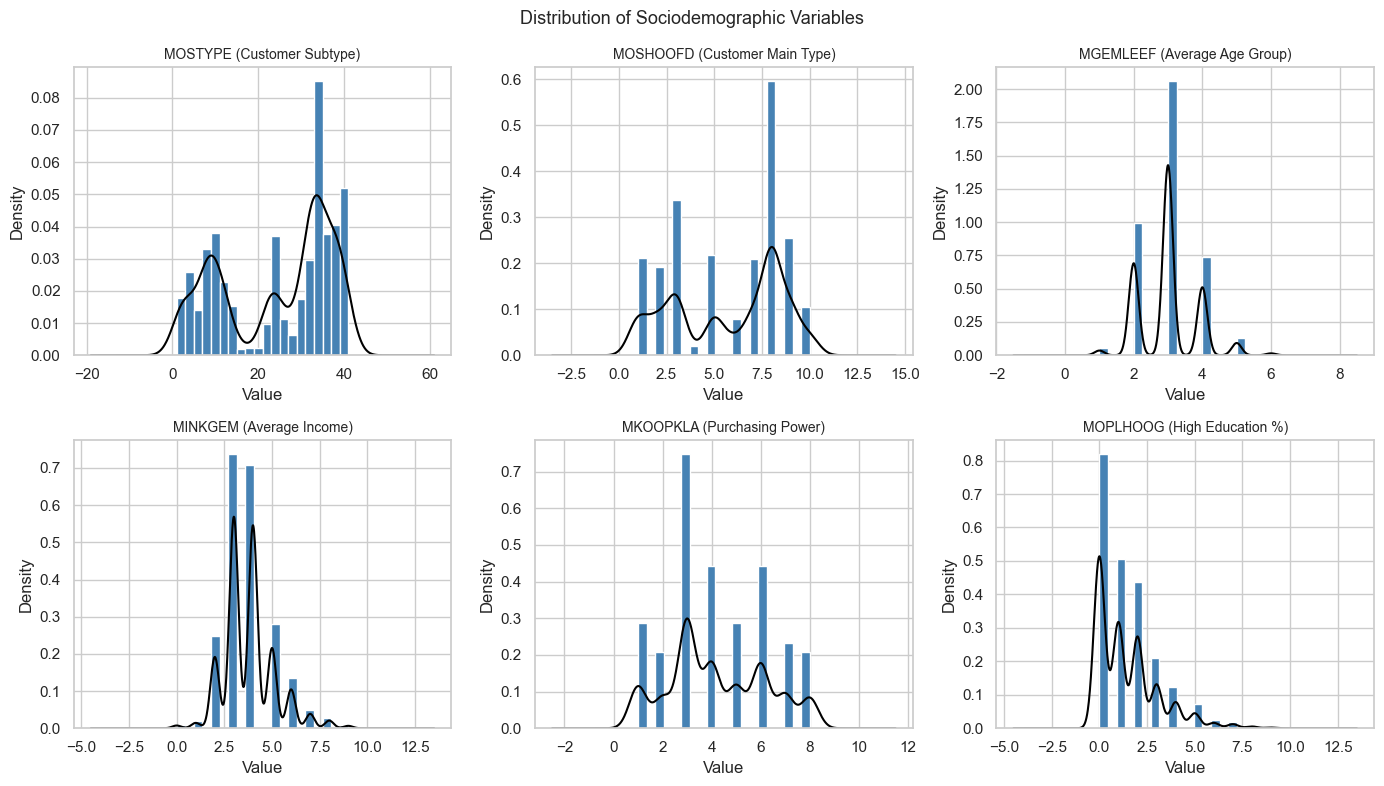

In [10]:
# Visualizing the distribution of key sociodemographic variables
# Histograms show the shape of each distribution
# I'm adding a density curve (KDE) on top so I can see the overall trend more clearly

# Setting up a 2x3 grid so all 6 plots appear together in one clean figure
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# flatten() converts the 2D grid of axes into a simple list
# so I can loop through them one by one
axes = axes.flatten()

socio_vars = ['MOSTYPE', 'MOSHOOFD', 'MGEMLEEF', 'MINKGEM', 'MKOOPKLA', 'MOPLHOOG']
socio_titles = [
    'MOSTYPE (Customer Subtype)',
    'MOSHOOFD (Customer Main Type)',
    'MGEMLEEF (Average Age Group)',
    'MINKGEM (Average Income)',
    'MKOOPKLA (Purchasing Power)',
    'MOPLHOOG (High Education %)'
]

for i, (col, title) in enumerate(zip(socio_vars, socio_titles)):
    # density=True scales the histogram so it matches the KDE curve
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', density=True)
    # KDE (Kernel Density Estimate) draws a smooth curve over the histogram
    df[col].plot.kde(ax=axes[i], color='black', linewidth=1.5)
    axes[i].set_title(title, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

# suptitle adds one main title above all 6 plots
plt.suptitle('Distribution of Sociodemographic Variables', fontsize=13)
plt.tight_layout()
plt.show()

The sociodemographic distributions reveal two distinct patterns. MGEMLEEF (average age 
group), MINKGEM (average income), and MOPLHOOG (high education %) follow relatively 
smooth distributions that track closely with their density curves.

However MOSTYPE 
(customer subtype), MOSHOOFD (customer main type), and MKOOPKLA (purchasing power) 
show irregular multimodal distributions with multiple peaks, suggesting that customers 
naturally cluster into distinct demographic groups rather than spreading evenly across 
the range. This supports the idea that meaningful customer segments exist within this 
dataset and will be worth exploring in the clustering analysis later.

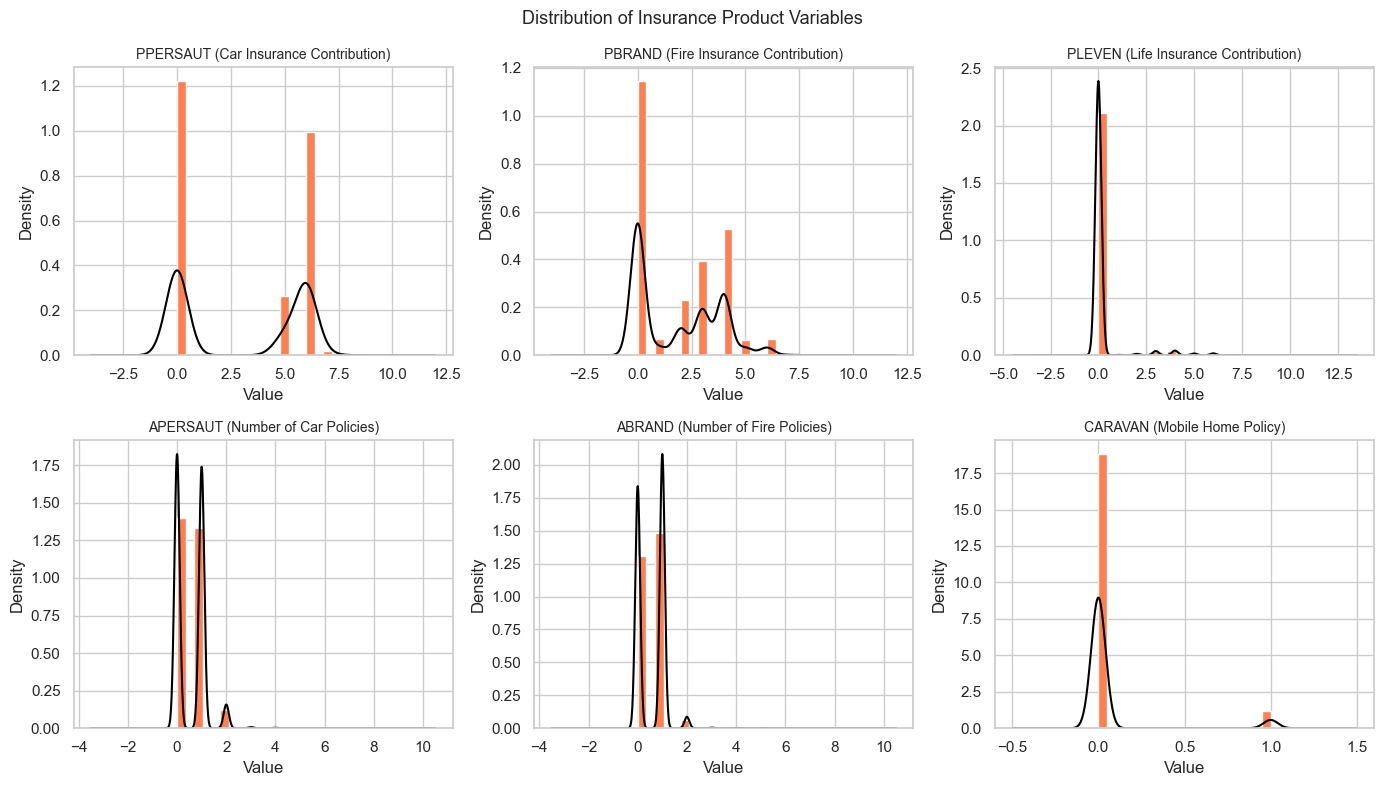

In [11]:
# Visualizing the distribution of key insurance product variables
# These are the variables that describe what customers actually buy
# I'm using the same histogram + KDE approach for consistency

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# flatten() so I can loop through the grid easily
axes = axes.flatten()

product_vars = ['PPERSAUT', 'PBRAND', 'PLEVEN', 'APERSAUT', 'ABRAND', 'CARAVAN']
product_titles = [
    'PPERSAUT (Car Insurance Contribution)',
    'PBRAND (Fire Insurance Contribution)',
    'PLEVEN (Life Insurance Contribution)',
    'APERSAUT (Number of Car Policies)',
    'ABRAND (Number of Fire Policies)',
    'CARAVAN (Mobile Home Policy)'
]

for i, (col, title) in enumerate(zip(product_vars, product_titles)):
    # density=True so histogram scale matches the KDE curve
    axes[i].hist(df[col], bins=20, color='coral', edgecolor='white', density=True)
    # KDE smooth curve on top
    df[col].plot.kde(ax=axes[i], color='black', linewidth=1.5)
    axes[i].set_title(title, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

plt.suptitle('Distribution of Insurance Product Variables', fontsize=13)
plt.tight_layout()
plt.show()

The insurance product distributions reveal clear differences in what customers actually 
purchase. PBRAND (fire insurance contribution) shows the most widespread adoption, with 
customers spread across multiple contribution levels suggesting it is the most commonly 
purchased product across different income groups. PPERSAUT (car insurance contribution) 
shows two distinct groups, those who contribute nothing and those who contribute 
significantly, indicating car insurance is common but not universal. PLEVEN (life 
insurance contribution) and CARAVAN (mobile home policy) are heavily concentrated at 
zero, confirming that these are niche products owned by only a small portion of the 
customer base. This pattern suggests that fire insurance is the baseline product for 
this customer population, while life and mobile home policies are selective purchases 
tied to specific customer profiles.

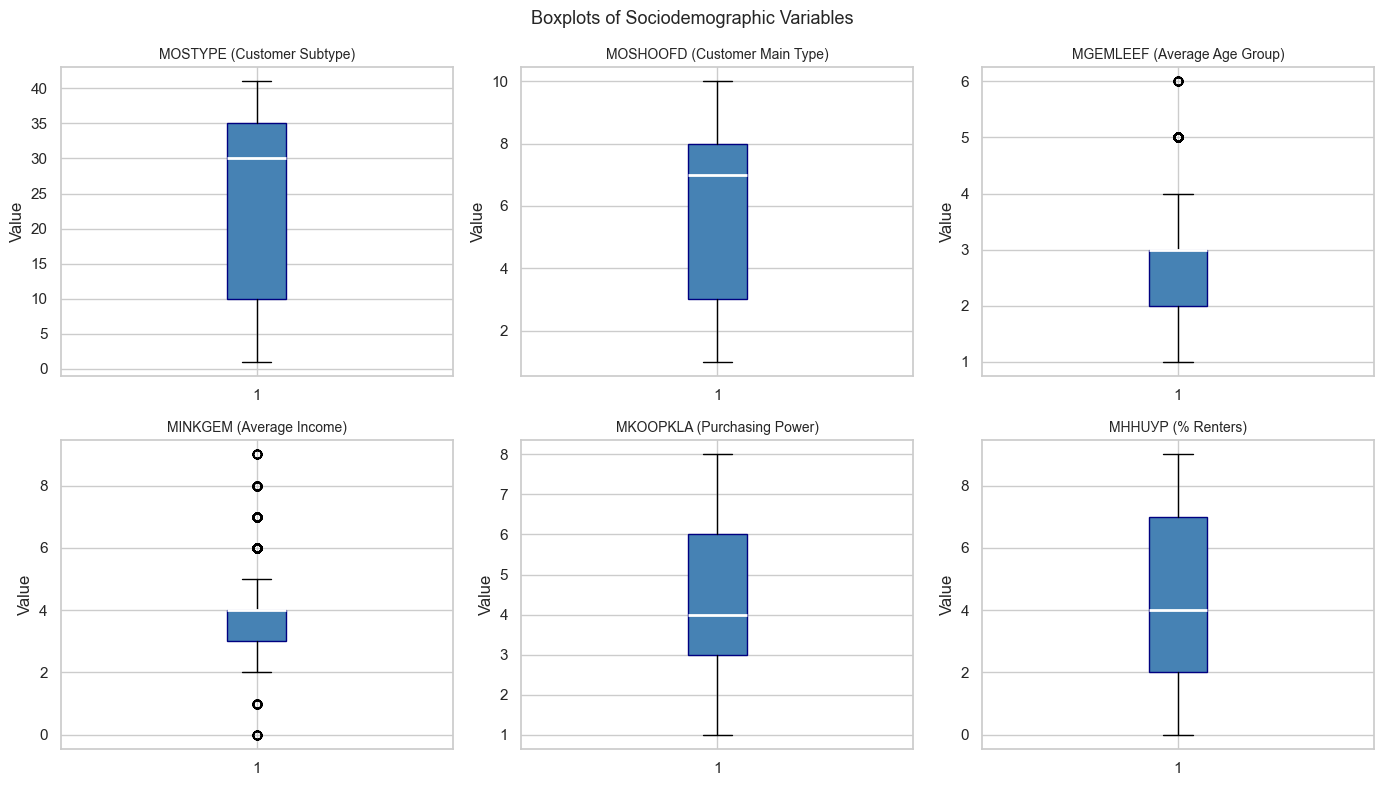

In [12]:
# Boxplots to visualize outliers in key variables
# Boxplots show the median, interquartile range, and any extreme values that fall outside the whiskers
# This helps identify whether outlier treatment is needed before modeling

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (col, title) in enumerate(zip(key_vars[:6], [
    'MOSTYPE (Customer Subtype)',
    'MOSHOOFD (Customer Main Type)',
    'MGEMLEEF (Average Age Group)',
    'MINKGEM (Average Income)',
    'MKOOPKLA (Purchasing Power)',
    'MHHUУР (% Renters)'
])):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='white', linewidth=2))
    axes[i].set_title(title, fontsize=10)
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots of Sociodemographic Variables', fontsize=13)
plt.tight_layout()
plt.show()

The boxplots confirm what the histograms suggested. MOSTYPE (customer subtype) and MOSHOOFD (customer main type) show wide interquartile ranges, reflecting the broad spread of customer categories in this dataset. MGEMLEEF (average age group) is tightly distributed around the middle values with only two high outliers, suggesting most customers fall in similar age brackets. MINKGEM (average income) shows several outlier points on both ends, with a few zip codes having notably higher or lower average incomes than the majority. Overall, no extreme outliers require removal, the spread reflects genuine variation across zip code demographics rather than data errors.

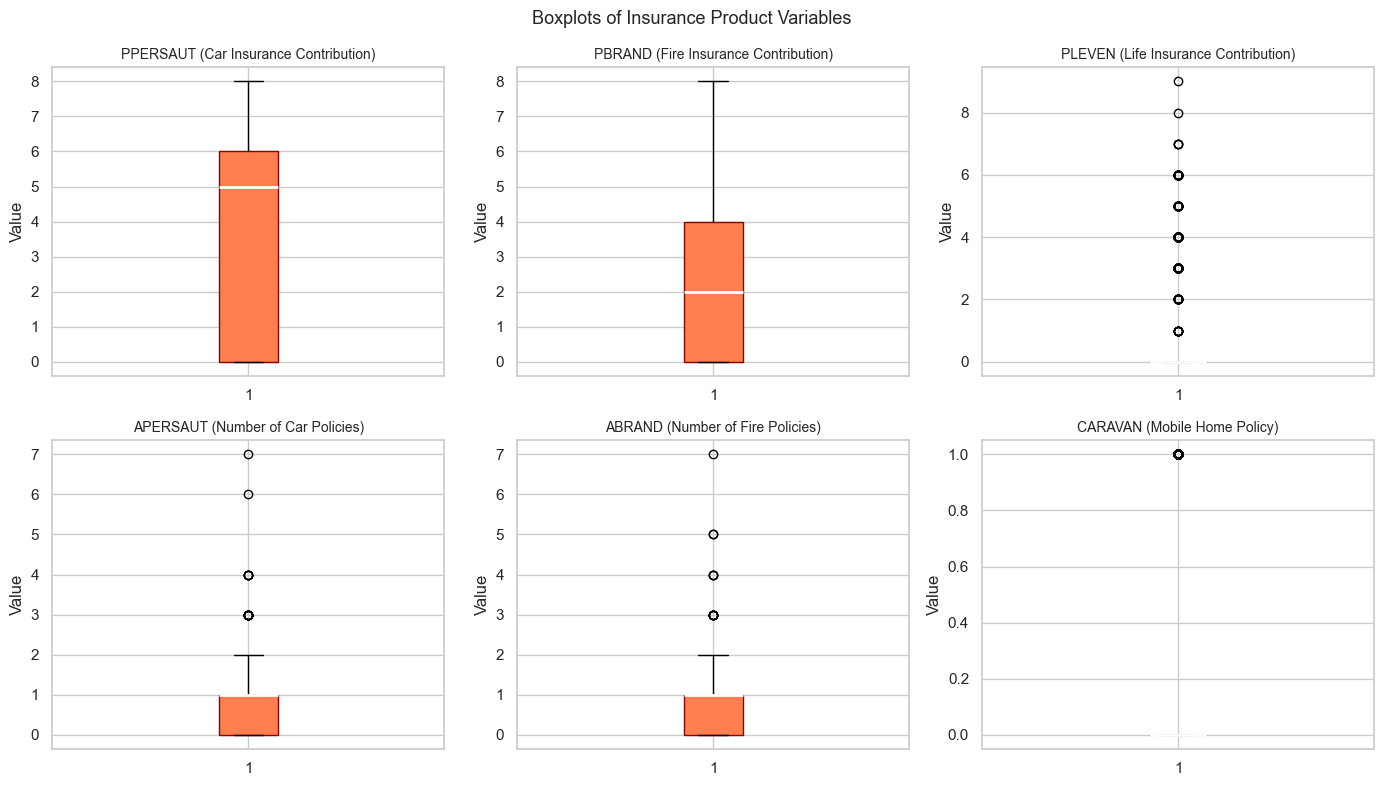

In [13]:
# Boxplots for insurance product variables
# These are expected to be heavily skewed since most customers hold zero policies
# The outlier dots above the whiskers represent the minority of customers who do hold those products

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (col, title) in enumerate(zip(product_vars, product_titles)):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='coral', color='darkred'),
                    medianprops=dict(color='white', linewidth=2))
    axes[i].set_title(title, fontsize=10)
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots of Insurance Product Variables', fontsize=13)
plt.tight_layout()
plt.show()

The insurance product boxplots reveal stark differences across product types. PPERSAUT (car insurance contribution) and PBRAND (fire insurance contribution) have meaningful IQR boxes, indicating that customers who do hold these products vary in their contribution levels. PLEVEN (life insurance contribution) is almost entirely collapsed at zero with all non-zero values appearing as individual outlier dots, confirming it is a niche product held by very few customers. APERSAUT and ABRAND (policy counts) show the same pattern, most customers hold zero or one policy, with a small number of outliers holding several. CARAVAN is binary, so its boxplot shows only a collapsed box at zero with the value of 1 appearing as a single outlier dot. None of these outliers will be removed as they represent real customers who genuinely hold these policies.

## EDA Task 3: Bivariate Analysis

### 3a. Covariance and Correlation

In this section I examine relationships between pairs of variables. Pearson correlation is used for continuous variables, as it measures the strength and direction of linear relationships between two variables.

In [14]:
# Pearson correlation matrix for key variables
# Values range from -1 (perfect negative) to +1 (perfect positive)
# 0 means no linear relationship between the two variables

corr_matrix = df[key_vars].corr(method='pearson')

print("Pearson Correlation Matrix:")
corr_matrix.round(3)

Pearson Correlation Matrix:


,MOSTYPE,MOSHOOFD,MGEMLEEF,MINKGEM,MKOOPKLA,MHHUUR,MHKOOP,MOPLHOOG,MAUT1,MAUT0,PPERSAUT,PBRAND,PLEVEN,APERSAUT,ABRAND,CARAVAN
MOSTYPE,1.000,0.993,0.009,-0.300,-0.568,0.149,-0.150,-0.474,-0.178,0.155,-0.008,-0.010,-0.043,-0.008,-0.012,-0.069
MOSHOOFD,0.993,1.000,0.004,-0.283,-0.536,0.118,-0.119,-0.472,-0.166,0.125,-0.006,-0.000,-0.040,-0.006,-0.012,-0.069
MGEMLEEF,0.009,0.004,1.000,-0.076,-0.145,0.025,-0.023,-0.026,-0.133,0.198,-0.015,0.019,-0.029,-0.016,0.024,0.004
MINKGEM,-0.300,-0.283,-0.076,1.000,0.452,-0.426,0.425,0.425,0.226,-0.381,0.024,0.080,0.032,0.027,0.021,0.090
MKOOPKLA,-0.568,-0.536,-0.145,0.452,1.000,-0.428,0.428,0.398,0.270,-0.399,0.023,0.100,0.067,0.034,0.024,0.096
MHHUUR,0.149,0.118,0.025,-0.426,-0.428,1.000,-1.000,-0.231,-0.188,0.395,-0.009,-0.183,-0.038,-0.021,-0.082,-0.079
MHKOOP,-0.150,-0.119,-0.023,0.425,0.428,-1.000,1.000,0.229,0.190,-0.396,0.008,0.183,0.040,0.021,0.082,0.078
MOPLHOOG,-0.474,-0.472,-0.026,0.425,0.398,-0.231,0.229,1.000,0.138,-0.157,-0.001,0.027,0.028,0.006,0.016,0.085
MAUT1,-0.178,-0.166,-0.133,0.226,0.270,-0.188,0.190,0.138,1.000,-0.735,0.047,0.020,0.031,0.047,-0.009,0.070
MAUT0,0.155,0.125,0.198,-0.381,-0.399,0.395,-0.396,-0.157,-0.735,1.000,-0.053,-0.078,-0.041,-0.057,-0.009,-0.077


The correlation matrix reveals two clusters of strong relationships. Within the sociodemographic 
group, MOSTYPE (customer subtype) and MOSHOOFD (customer main type) are nearly perfectly 
correlated (0.993), which makes sense since MOSHOOFD is simply a broader grouping of the MOSTYPE 
categories. MHHUUR (rented house %) and MHKOOP (home owners %) show a perfect negative 
correlation of -1.000, confirming they are mirror images of each other within each zip code. 
MAUT1 (% with 1 car) and MAUT0 (% with no car) follow the same inverse pattern at -0.735. 
Within the insurance product group, PPERSAUT (car insurance contribution) and APERSAUT (number 
of car policies) show a very strong correlation of 0.916, and PBRAND (fire insurance 
contribution) and ABRAND (number of fire policies) follow at 0.866, both reflecting that 
contribution amounts scale directly with the number of policies held. Notably, correlations 
between sociodemographic variables and insurance product variables are almost all near zero, 
suggesting that zip code demographics alone do not linearly predict individual product ownership.

### 3b. Visualizations

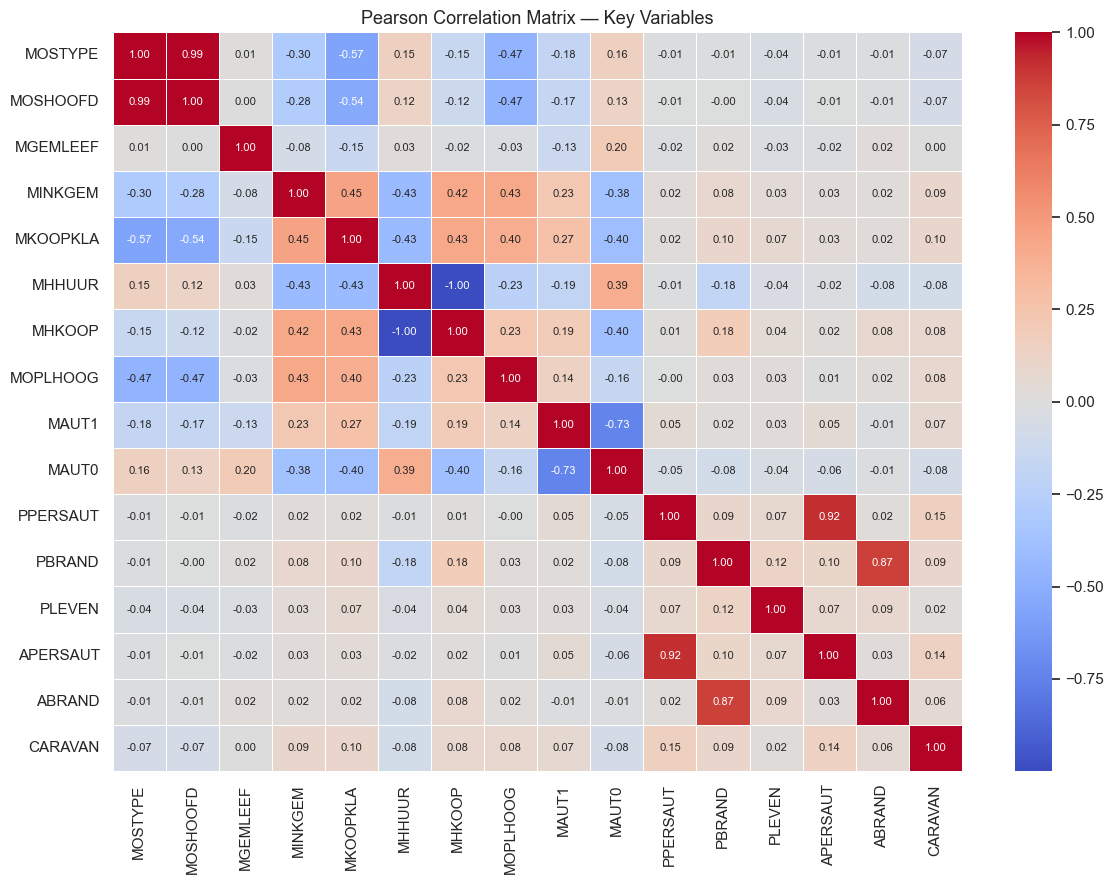

In [15]:
# Heatmap of the Pearson correlation matrix
# Makes it much easier to spot strong relationships at a glance
# Dark blue = strong positive correlation, dark red = strong negative correlation
# The diagonal is always 1.0 since a variable is perfectly correlated with itself

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,             # show the actual correlation values in each cell
    fmt='.2f',              # round to 2 decimal places
    cmap='coolwarm',        # blue-white-red color scale
    center=0,               # center the colormap at 0 so neutral = white
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Pearson Correlation Matrix — Key Variables', fontsize=13)
plt.tight_layout()
plt.show()

The heatmap makes the two relationship clusters immediately visible. The upper-left block 
(sociodemographic variables) shows several moderate to strong correlations, particularly the 
deep red MOSTYPE (customer subtype) and MOSHOOFD (customer main type) pair, and the deep blue 
MHHUUR (rented house %) and MHKOOP (home owners %) pair. The lower-right block (insurance 
product variables) shows the strong PPERSAUT (car insurance contribution) and APERSAUT (number 
of car policies), and PBRAND (fire insurance contribution) and ABRAND (number of fire policies) 
pairs in deep red. The off-diagonal region between the two blocks is almost entirely white, 
visually confirming that demographic and product variables are largely uncorrelated with each other.

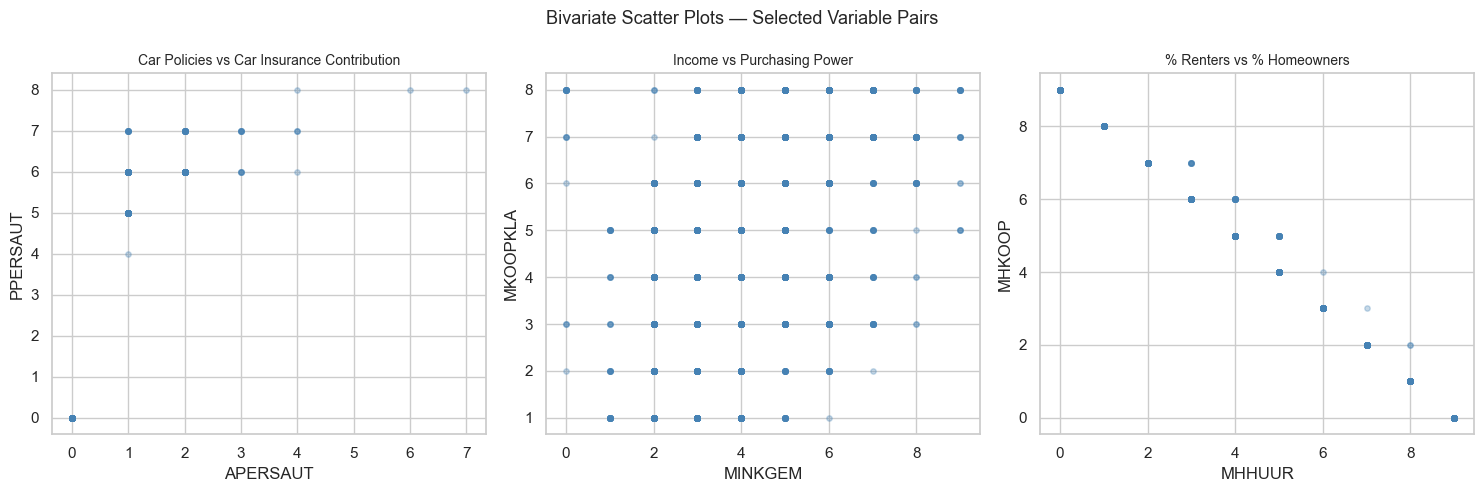

In [16]:
# Scatter plots for selected variable pairs that showed meaningful correlations
# Each plot visualizes the direction and strength of the relationship between two variables

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [
    ('APERSAUT', 'PPERSAUT', 'Car Policies vs Car Insurance Contribution'),
    ('MINKGEM',  'MKOOPKLA', 'Income vs Purchasing Power'),
    ('MHHUUR',   'MHKOOP',   '% Renters vs % Homeowners'),
]

for ax, (x, y, title) in zip(axes, pairs):
    # alpha=0.3 makes points semi-transparent so overlapping dots are visible
    ax.scatter(df[x], df[y], alpha=0.3, s=15, color='steelblue')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title, fontsize=10)

plt.suptitle('Bivariate Scatter Plots — Selected Variable Pairs', fontsize=13)
plt.tight_layout()
plt.show()

The scatter plots reflect the ordinal and discrete nature of these variables. The APERSAUT 
(number of car policies) vs PPERSAUT (car insurance contribution) plot shows a clear upward 
staircase pattern, as the number of car policies increases, contribution levels rise in discrete 
steps rather than a smooth line, which is consistent with how insurance contributions are 
structured. The MINKGEM (average income) vs MKOOPKLA (purchasing power class) plot shows a broad 
grid of dots with a general upward trend, confirming a moderate positive relationship but with 
considerable spread, meaning income level is not a precise predictor of purchasing power class on 
its own. The MHHUUR (rented house %) vs MHKOOP (home owners %) plot produces a tight downward 
staircase, visually confirming the near-perfect negative correlation, as the percentage of 
renters rises, homeownership falls almost exactly in step.

## EDA Task 4: Test Statistics

### 4a. Hypothesis Development

In this section I develop hypotheses about relationships in the data and select appropriate 
statistical tests based on the variable types involved. For each test I will discuss the 
assumptions and whether they hold for this dataset.

In [17]:
# Test 1: Independent Samples T-Test
# Hypothesis: Customers who own a mobile home policy (CARAVAN=1) have higher average 
# income (MINKGEM) than those who do not (CARAVAN=0)

# H0: There is no difference in average income between CARAVAN owners and non-owners
# H1: CARAVAN owners have a significantly higher average income than non-owners

# Splitting the data into two groups based on CARAVAN ownership
caravan_yes = df[df['CARAVAN'] == 1]['MINKGEM']
caravan_no  = df[df['CARAVAN'] == 0]['MINKGEM']

# Running the independent samples t-test
# equal_var=False uses Welch's t-test which does not assume equal variance between groups
t_stat, p_value = ttest_ind(caravan_yes, caravan_no, equal_var=False)

print("Independent Samples T-Test: MINKGEM (average income) by CARAVAN (mobile home policy)")
print(f"  CARAVAN = 1 — Mean income: {caravan_yes.mean():.3f}, N = {len(caravan_yes)}")
print(f"  CARAVAN = 0 — Mean income: {caravan_no.mean():.3f},  N = {len(caravan_no)}")
print(f"\n  T-statistic: {t_stat:.4f}")
print(f"  P-value:     {p_value:.4f}")
print(f"\n  Result: {'Reject H0' if p_value < 0.05 else 'Fail to reject H0'} at alpha = 0.05")

Independent Samples T-Test: MINKGEM (average income) by CARAVAN (mobile home policy)
  CARAVAN = 1 — Mean income: 4.256, N = 348
  CARAVAN = 0 — Mean income: 3.754,  N = 5474

  T-statistic: 6.9940
  P-value:     0.0000

  Result: Reject H0 at alpha = 0.05


**Assumptions:** The independent samples t-test assumes that the two groups are independent, 
which holds here since a customer either owns a mobile home policy or does not. It also assumes 
approximate normality within each group. Given the large sample size (N = 5,474 non-owners and 
N = 348 owners), the Central Limit Theorem applies and normality is reasonably satisfied. 
Welch's t-test was used rather than the standard t-test because equal variance between groups 
cannot be assumed given the large difference in group sizes.

**Result:** The t-statistic of 6.994 and a p-value of essentially 0 lead us to reject the null 
hypothesis. CARAVAN (mobile home policy) owners have a meaningfully higher mean income 
(MINKGEM = 4.256) compared to non-owners (MINKGEM = 3.754). This suggests that income level 
is a statistically significant differentiator between customers who own a mobile home policy 
and those who do not, which aligns with the expectation that mobile home ownership is 
associated with higher purchasing power.

In [18]:
# Test 2: Chi-Squared Test of Independence
# Hypothesis: CARAVAN (mobile home policy) ownership is not independent of 
# MAUT1 (percentage of 1-car households in the zip code)

# H0: CARAVAN ownership and MAUT1 car ownership rate are independent
# H1: There is a significant association between CARAVAN ownership and MAUT1

# Chi-squared requires categorical variables
# MAUT1 is already ordinal (0-9 scale), CARAVAN is binary
# Building a contingency table of observed frequencies
contingency_table = pd.crosstab(df['CARAVAN'], df['MAUT1'])

# Running the chi-squared test
chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)

print("Chi-Squared Test of Independence: CARAVAN (mobile home policy) vs MAUT1 (% with 1 car)")
print(f"\n  Chi-squared statistic: {chi2:.4f}")
print(f"  Degrees of freedom:    {dof}")
print(f"  P-value:               {p_chi2:.4f}")
print(f"\n  Result: {'Reject H0' if p_chi2 < 0.05 else 'Fail to reject H0'} at alpha = 0.05")

Chi-Squared Test of Independence: CARAVAN (mobile home policy) vs MAUT1 (% with 1 car)

  Chi-squared statistic: 36.9903
  Degrees of freedom:    9
  P-value:               0.0000

  Result: Reject H0 at alpha = 0.05


**Assumptions:** The chi-squared test of independence assumes that observations are independent 
and that expected cell frequencies are sufficiently large (generally at least 5). Both 
conditions are met here, customers are independent records and the sample size of 5,822 is 
large enough to produce adequate expected frequencies across all cells of the contingency table.

**Result:** The chi-squared statistic of 36.990 with 9 degrees of freedom and a p-value of 
essentially 0 leads us to reject the null hypothesis. CARAVAN (mobile home policy) ownership 
is not independent of MAUT1 (percentage of 1-car households in the zip code). This suggests 
that the car ownership profile of a customer's zip code is associated with whether they hold 
a mobile home policy, which is consistent with the idea that mobile home owners tend to live 
in areas with higher car ownership rates.

In [19]:
# Test 3: One-Way ANOVA
# Hypothesis: Average income (MINKGEM) differs significantly across customer main types (MOSHOOFD)

# H0: Mean income is the same across all MOSHOOFD (customer main type) groups
# H1: At least one customer main type group has a significantly different mean income

# ANOVA compares means across 3 or more groups
# MOSHOOFD has 10 categories (1-10), making ANOVA appropriate here

# Creating a list of MINKGEM values for each MOSHOOFD group
groups = [df[df['MOSHOOFD'] == g]['MINKGEM'].values for g in sorted(df['MOSHOOFD'].unique())]

# Running the one-way ANOVA
f_stat, p_anova = f_oneway(*groups)

print("One-Way ANOVA: MINKGEM (average income) across MOSHOOFD (customer main type) groups")
print(f"\n  Number of groups: {len(groups)}")
print(f"  F-statistic:      {f_stat:.4f}")
print(f"  P-value:          {p_anova:.4f}")
print(f"\n  Result: {'Reject H0' if p_anova < 0.05 else 'Fail to reject H0'} at alpha = 0.05")

One-Way ANOVA: MINKGEM (average income) across MOSHOOFD (customer main type) groups

  Number of groups: 10
  F-statistic:      169.1818
  P-value:          0.0000

  Result: Reject H0 at alpha = 0.05


**Assumptions:** One-way ANOVA assumes independence of observations, approximate normality 
within each group, and homogeneity of variance across groups. Independence holds since each 
customer record is separate. With 10 groups ranging across the full MOSHOOFD (customer main 
type) classification, the Central Limit Theorem supports normality given adequate group sizes. 
Homogeneity of variance is an assumption that may not hold perfectly across all 10 customer 
types, which is a limitation to note.

**Result:** The F-statistic of 169.182 and a p-value of essentially 0 lead us to reject the 
null hypothesis. Average income (MINKGEM) differs significantly across the 10 MOSHOOFD 
(customer main type) groups. This confirms that customer segments are not economically 
homogeneous, different customer main types occupy meaningfully different income brackets, 
which has important implications for targeting and product recommendation strategies.

## EDA Task 5: Regression and Classification

### 5a. Regression Analysis

For the regression task I will predict PPERSAUT (car insurance contribution) using 
sociodemographic variables. This is a continuous target variable making linear regression 
an appropriate choice.

In [20]:
# Linear Regression: Predicting PPERSAUT (car insurance contribution)
# from sociodemographic variables
# I'm using income, purchasing power, age, education, and car ownership rate as predictors
# since these are the demographic variables most logically connected to car insurance behavior

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Defining predictor variables (X) and target variable (y)
reg_features = ['MINKGEM', 'MKOOPKLA', 'MGEMLEEF', 'MOPLHOOG', 'MAUT1', 'MAUT0']
X_reg = df[reg_features]
y_reg = df['PPERSAUT']

# Splitting into training (80%) and test (20%) sets
# random_state=42 ensures the same split every time the code is run
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Fitting the linear regression model on the training set
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

# Generating predictions on the test set
y_pred_reg = reg_model.predict(X_test_reg)

print("Linear Regression: Predicting PPERSAUT (car insurance contribution)")
print(f"\n  R-squared:  {r2_score(y_test_reg, y_pred_reg):.4f}")
print(f"  MAE:        {mean_absolute_error(y_test_reg, y_pred_reg):.4f}")
print(f"  RMSE:       {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.4f}")

print("\n  Coefficients:")
for feat, coef in zip(reg_features, reg_model.coef_):
    print(f"    {feat}: {coef:.4f}")
print(f"  Intercept: {reg_model.intercept_:.4f}")

Linear Regression: Predicting PPERSAUT (car insurance contribution)

  R-squared:  -0.0001
  MAE:        2.9066
  RMSE:       2.9291

  Coefficients:
    MINKGEM: 0.0140
    MKOOPKLA: 0.0241
    MGEMLEEF: -0.0361
    MOPLHOOG: -0.0369
    MAUT1: 0.0266
    MAUT0: -0.0710
  Intercept: 2.9563


**Result and Interpretation:** The linear regression model performed very poorly, returning an 
R-squared of essentially 0 (-0.0001). This means the sociodemographic variables selected, 
MINKGEM (average income), MKOOPKLA (purchasing power class), MGEMLEEF (average age group), 
MOPLHOOG (high level education %), MAUT1 (% with 1 car), and MAUT0 (% with no car), explain 
virtually none of the variance in PPERSAUT (car insurance contribution). The coefficients are 
all very close to zero, and the intercept of 2.956 is nearly identical to the mean of PPERSAUT 
(2.97 from the descriptive statistics), meaning the model is essentially just predicting the 
mean for every customer regardless of their demographic profile.

This result is consistent with what the correlation matrix showed in Task 3 — sociodemographic 
variables have near-zero correlations with insurance product variables. Car insurance contribution 
is likely driven more by individual-level decisions and policy details than by neighborhood 
demographics, which are the only predictors available in this dataset.

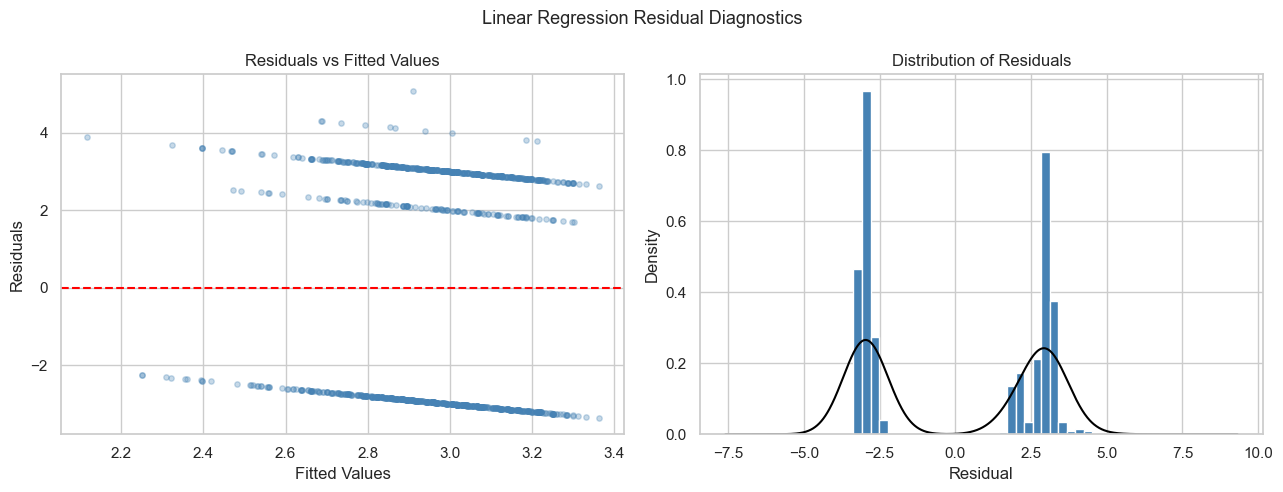

In [21]:
# Residual plot to check regression assumptions
# Residuals should be randomly scattered around zero with no clear pattern
# A pattern in residuals would suggest the linear model is missing something

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: residuals vs fitted values
# Looking for random scatter around the horizontal zero line
residuals = y_test_reg - y_pred_reg
axes[0].scatter(y_pred_reg, residuals, alpha=0.3, s=15, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values')

# Right plot: distribution of residuals
# Should be approximately bell-shaped if normality assumption holds
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', density=True)
residuals.plot.kde(ax=axes[1], color='black', linewidth=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of Residuals')

plt.suptitle('Linear Regression Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.show()

**Residual Diagnostics:** The residual plots reveal a clear violation of linear regression 
assumptions. The residuals vs fitted values plot shows two distinct horizontal bands rather 
than random scatter around zero, indicating that the model's errors are not randomly distributed. 
This banding pattern reflects the discrete, ordinal nature of PPERSAUT (car insurance 
contribution), because the target variable takes only a limited set of integer values, 
the residuals cluster in structured groups rather than spreading continuously. The distribution 
of residuals shows a bimodal shape with two separated peaks, further confirming that a linear 
model is not appropriate for this target variable. These diagnostics suggest that a different 
modeling approach, such as ordinal regression or a tree-based model, would be better suited 
for predicting PPERSAUT (car insurance contribution).

### 5b. Classification Model

For the classification task I will predict CARAVAN (mobile home policy ownership) using 
sociodemographic and insurance product variables. Since CARAVAN is binary (0 or 1), 
logistic regression is a natural and interpretable starting point.

In [22]:
# Logistic Regression: Predicting CARAVAN (mobile home policy ownership)
# CARAVAN is binary (0 = no policy, 1 = owns policy) making this a binary classification problem
# I'm using both sociodemographic and insurance product variables as predictors

clf_features = ['MINKGEM', 'MKOOPKLA', 'MGEMLEEF', 'MOPLHOOG',
                'MAUT1', 'PPERSAUT', 'PBRAND', 'APERSAUT', 'ABRAND']

X_clf = df[clf_features]
y_clf = df['CARAVAN']

# Splitting into training (80%) and test (20%) sets
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# Scaling features before logistic regression
# Logistic regression is sensitive to variable scale
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled  = scaler_clf.transform(X_test_clf)

# class_weight='balanced' adjusts for the heavy class imbalance
# since only ~6% of customers own a CARAVAN policy
log_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_model.fit(X_train_clf_scaled, y_train_clf)

y_pred_clf = log_model.predict(X_test_clf_scaled)
y_prob_clf = log_model.predict_proba(X_test_clf_scaled)[:, 1]

print("Logistic Regression: Predicting CARAVAN (mobile home policy ownership)")
print(f"\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf))
print(f"ROC-AUC Score: {roc_auc_score(y_test_clf, y_prob_clf):.4f}")

Logistic Regression: Predicting CARAVAN (mobile home policy ownership)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.68      0.80      1084
           1       0.14      0.72      0.24        81

    accuracy                           0.68      1165
   macro avg       0.56      0.70      0.52      1165
weighted avg       0.91      0.68      0.76      1165

ROC-AUC Score: 0.7565


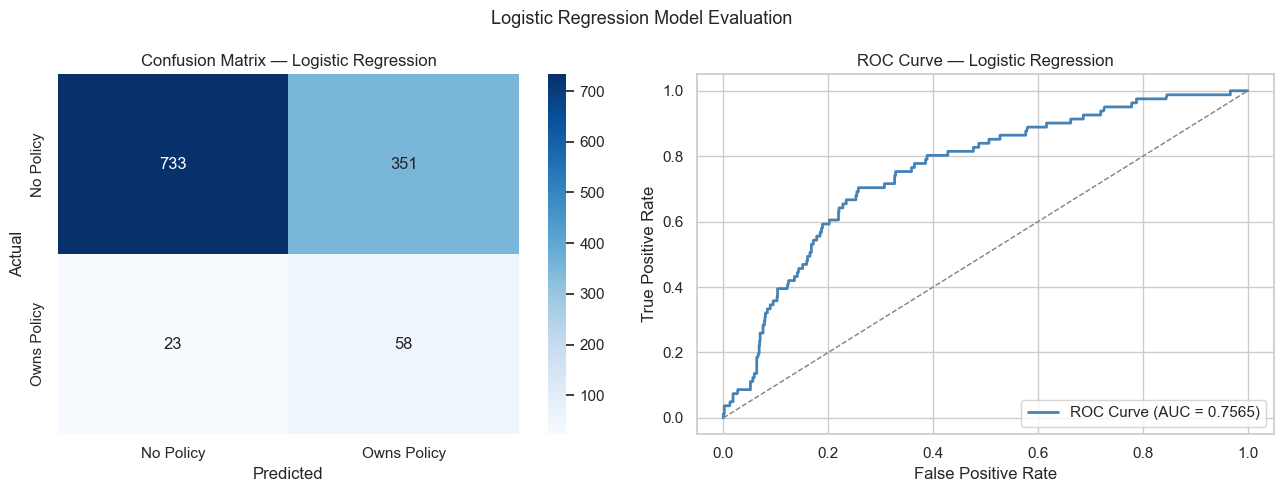

In [23]:
# Visualizing classification performance with a confusion matrix and ROC curve
# Confusion matrix shows how many predictions were correct vs incorrect for each class
# ROC curve shows the tradeoff between true positive rate and false positive rate

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Confusion matrix heatmap
cm = confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Policy', 'Owns Policy'],
            yticklabels=['No Policy', 'Owns Policy'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix — Logistic Regression')

# Right: ROC curve
# The closer the curve hugs the top-left corner, the better the model
fpr, tpr, _ = roc_curve(y_test_clf, y_prob_clf)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'ROC Curve (AUC = {roc_auc_score(y_test_clf, y_prob_clf):.4f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Logistic Regression')
axes[1].legend(loc='lower right')

plt.suptitle('Logistic Regression Model Evaluation', fontsize=13)
plt.tight_layout()
plt.show()

**Result and Interpretation:** The logistic regression model produced an ROC-AUC score of 
0.7565, indicating moderate discriminative ability, the model is meaningfully better than 
random guessing (AUC = 0.50) at distinguishing CARAVAN (mobile home policy) owners from 
non-owners. The ROC curve rises sharply in the early portion before flattening, suggesting 
the model captures the most obvious positive cases well but struggles with borderline ones.

The confusion matrix highlights the challenge of class imbalance. Of the 81 actual policy 
owners in the test set, the model correctly identified 58 (recall = 0.72), which is 
reasonable given how rare this class is. However precision for the positive class is only 
0.14, meaning the model also flags many non-owners as owners (351 false positives). This 
tradeoff is a direct consequence of using class_weight='balanced' to compensate for the 
heavily imbalanced dataset where only about 6% of customers own a mobile home policy. 
Depending on the business use case, this tradeoff may be acceptable, in a marketing 
campaign context it is generally preferable to cast a wide net and tolerate false positives 
rather than miss true policy owners entirely.

## EDA Task 6: Advanced Analysis Techniques

### 6a. Clustering Analysis

In this section I apply K-Means clustering to identify natural customer segments within 
the dataset. Principal Component Analysis (PCA) is applied first to reduce dimensionality 
and allow the clusters to be visualized in two dimensions.

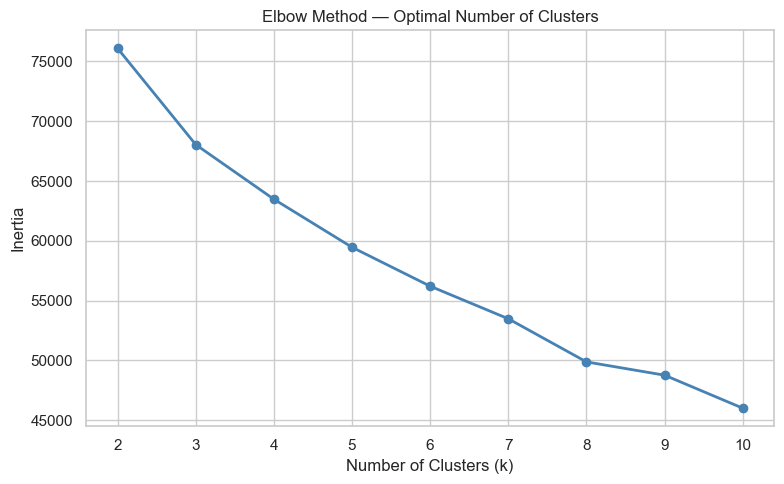

In [24]:
# Before running K-Means I need to determine the optimal number of clusters
# The elbow method plots inertia (within-cluster sum of squares) for different values of k
# The "elbow" point where inertia stops dropping sharply suggests the best k

inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

The elbow plot shows a gradual, consistent decline in inertia without a sharp elbow point. 
The curve begins to flatten more noticeably around k = 4, where the rate of improvement 
slows meaningfully compared to the steeper drop between k = 2 and k = 3. While this dataset 
does not produce a textbook elbow, k = 4 represents a reasonable balance between cluster 
compactness and interpretability, and will be used for the final model.

In [25]:
# Based on the elbow plot I will select k and fit the final K-Means model
# PCA reduces the 16 scaled key variables down to 2 components so the clusters can be plotted on a 2D scatter plot

# Fitting K-Means with chosen k
# n_init=10 runs the algorithm 10 times with different starting points and keeps the best result
k = 4
kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_scaled)

# Adding cluster labels back to the original dataframe for interpretation
df['Cluster'] = cluster_labels

# Applying PCA to reduce to 2 dimensions for visualization
# PCA finds the directions of maximum variance in the data
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(df_scaled)

print(f"K-Means clustering complete with k = {k}")
print(f"Variance explained by first 2 PCA components: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"\nCluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

K-Means clustering complete with k = 4
Variance explained by first 2 PCA components: 37.9%

Cluster sizes:
0    2024
1     344
2    1551
3    1903
Name: count, dtype: int64


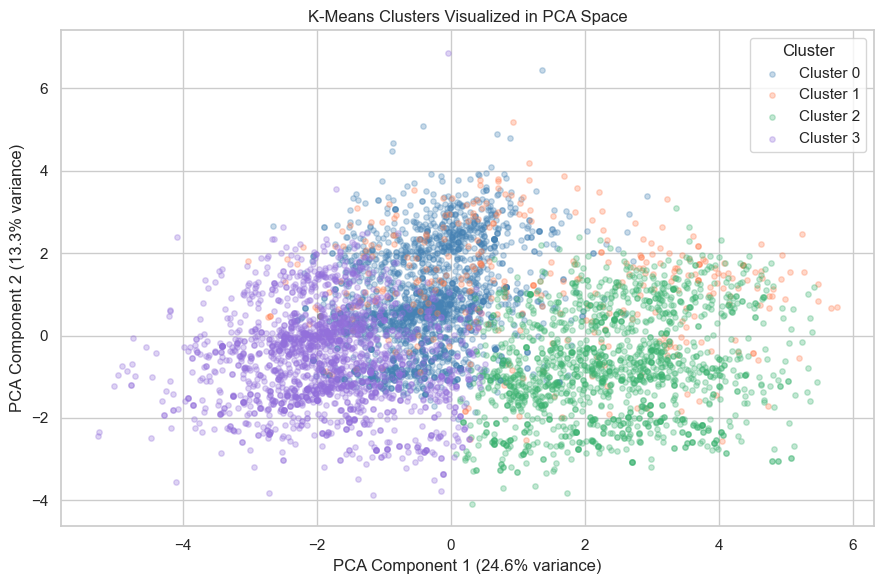

In [26]:
# Visualizing the clusters in PCA space
#Each dot is a customer, colored by their assigned cluster
#The separation between color groups shows how distinct the clusters are

plt.figure(figsize=(9, 6))

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
for i in range(k):
    mask = cluster_labels == i
    plt.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                alpha=0.3, s=15, color=colors[i], label=f'Cluster {i}')

plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-Means Clusters Visualized in PCA Space')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

The PCA plot shows four partially separated customer groups across the two principal 
components, which together explain 37.9% of the total variance in the key variables. 
While there is meaningful overlap between clusters, which is expected given that only 
37.9% of variance is captured in two dimensions, the clusters do occupy distinct regions 
of the space. Cluster 2 (green) spreads toward the right along PCA Component 1 
(24.6% variance), Cluster 3 (purple) occupies the left side, and Clusters 0 and 1 sit 
in the middle with some overlap. The moderate separation suggests that the clusters 
reflect real underlying structure in the data rather than arbitrary divisions.

In [27]:
# Interpreting the clusters by comparing mean values across key variables
#This tells us what makes each cluster distinct demographically and behaviorally

cluster_profile = df.groupby('Cluster')[key_vars].mean().round(3)

print("Cluster Profile — Mean Values per Cluster:")
cluster_profile

Cluster Profile — Mean Values per Cluster:


,MOSTYPE,MOSHOOFD,MGEMLEEF,MINKGEM,MKOOPKLA,MHHUUR,MHKOOP,MOPLHOOG,MAUT1,MAUT0,PPERSAUT,PBRAND,PLEVEN,APERSAUT,ABRAND,CARAVAN
Cluster,,,,,,,,,,,,,,,,
0,35.030,8.236,2.985,3.819,3.664,2.627,6.383,0.888,6.026,1.647,2.843,2.208,0.165,0.545,0.644,0.000
1,20.599,4.965,3.000,4.282,5.044,3.203,5.797,2.023,6.494,1.439,4.738,2.552,0.273,0.913,0.712,1.000
2,7.666,2.161,2.952,4.660,6.533,2.446,6.567,2.671,6.767,1.133,2.868,2.009,0.295,0.545,0.593,0.000
3,26.971,6.245,3.028,2.944,2.827,7.595,1.409,0.982,5.382,3.060,2.870,1.144,0.131,0.531,0.448,0.002


The cluster profile table reveals four meaningfully distinct customer segments:

**Cluster 0** (n = 2,024) represents rural homeowners with average demographics. They show 
high MOSTYPE (customer subtype = 35.0, corresponding to village families and traditional 
households), moderate MINKGEM (average income = 3.82), low MOPLHOOG (high education % = 0.89), 
and high MHKOOP (home owners % = 6.38). Notably, CARAVAN (mobile home policy) ownership 
is 0.000, making this the least likely segment to hold a mobile home policy.

**Cluster 1** (n = 344) is the smallest but most distinctive segment. It has the highest 
MKOOPKLA (purchasing power class = 5.04), highest PPERSAUT (car insurance contribution = 4.74), 
highest APERSAUT (number of car policies = 0.91), and a CARAVAN (mobile home policy) ownership 
rate of 1.000 — meaning every customer in this cluster owns a mobile home policy. This is 
clearly the high-value mobile home owner segment and the primary target group for CARAVAN 
policy marketing.

**Cluster 2** (n = 1,551) represents affluent, educated homeowners. They show the lowest 
MOSTYPE values (7.67, corresponding to higher income subtypes), highest MINKGEM (average 
income = 4.66), highest MOPLHOOG (high education % = 2.67), and highest MKOOPKLA (purchasing 
power class = 6.53). Despite their wealth, CARAVAN ownership is 0.000, suggesting affluent 
customers prefer other insurance products.

**Cluster 3** (n = 1,903) represents lower-income renters. They show the lowest MINKGEM 
(average income = 2.94), lowest MKOOPKLA (purchasing power class = 2.83), highest MHHUUR 
(rented house % = 7.60), lowest MHKOOP (home owners % = 1.41), and the lowest PBRAND 
(fire insurance contribution = 1.14) and ABRAND (number of fire policies = 0.45) of all 
clusters. CARAVAN ownership is near zero (0.002), which is expected since renters are 
unlikely to own mobile homes.

### 6b. Machine Learning Approach to Classification

Here I apply a Random Forest classifier to predict CARAVAN (mobile home policy ownership), 
using the same features as the logistic regression in Task 5b. Random Forest is an ensemble 
method that builds multiple decision trees and combines their predictions, often outperforming 
logistic regression on imbalanced or nonlinear classification problems.

In [28]:
# Random Forest Classifier: Predicting CARAVAN (mobile home policy ownership)
# Using the same features and train/test split as the logistic regression for direct comparison
# class_weight='balanced' again to handle the heavy class imbalance (~6% positive class)

rf_model = RandomForestClassifier(
    n_estimators=100, # number of trees in the forest
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train_clf, y_train_clf)

y_pred_rf   = rf_model.predict(X_test_clf)
y_prob_rf   = rf_model.predict_proba(X_test_clf)[:, 1]

print("Random Forest: Predicting CARAVAN (mobile home policy ownership)")
print(f"\nClassification Report:")
print(classification_report(y_test_clf, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test_clf, y_prob_rf):.4f}")

Random Forest: Predicting CARAVAN (mobile home policy ownership)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      1084
           1       0.17      0.14      0.15        81

    accuracy                           0.89      1165
   macro avg       0.55      0.54      0.55      1165
weighted avg       0.88      0.89      0.89      1165

ROC-AUC Score: 0.6707


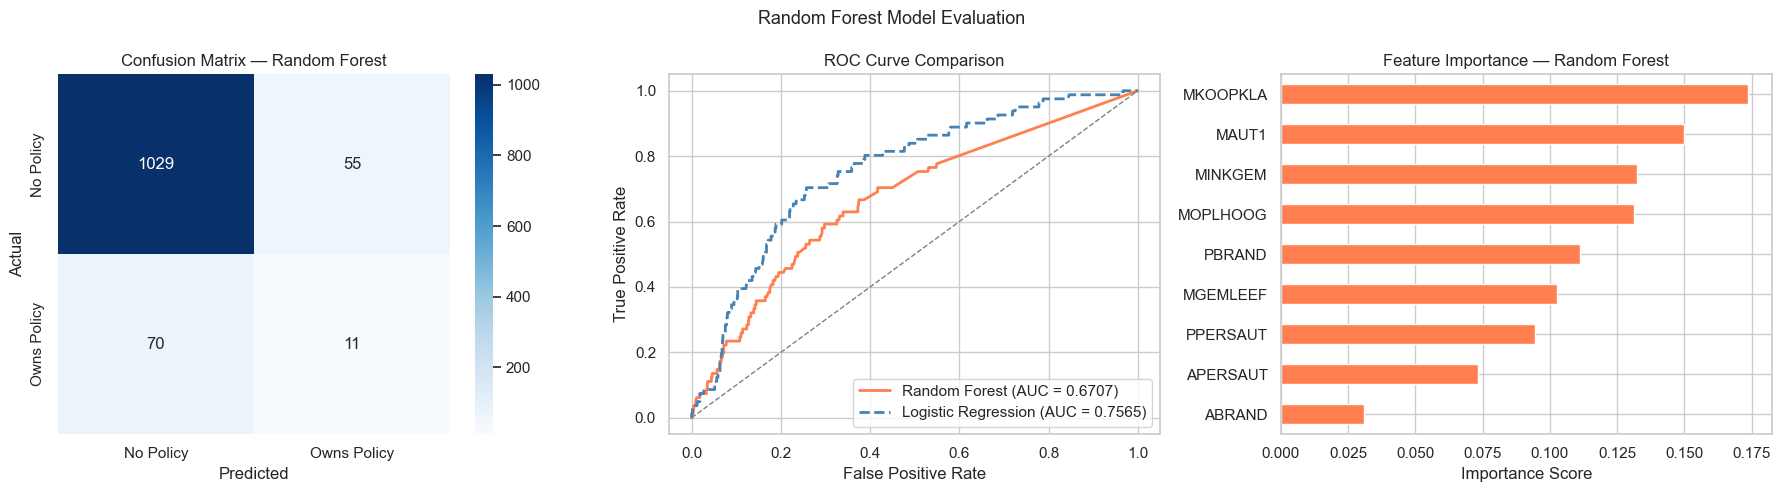

In [29]:
# Evaluating the Random Forest with a confusion matrix, ROC curve, and feature importance plot
# Feature importance shows which variables the model relied on most when making predictions

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Confusion matrix
cm_rf = confusion_matrix(y_test_clf, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Policy', 'Owns Policy'],
            yticklabels=['No Policy', 'Owns Policy'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix — Random Forest')

# Middle: ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test_clf, y_prob_rf)
axes[1].plot(fpr_rf, tpr_rf, color='coral', linewidth=2,
             label=f'Random Forest (AUC = {roc_auc_score(y_test_clf, y_prob_rf):.4f})')
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, linestyle='--',
             label=f'Logistic Regression (AUC = {roc_auc_score(y_test_clf, y_prob_clf):.4f})')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend(loc='lower right')

# Right: Feature importance
importances = pd.Series(rf_model.feature_importances_, index=clf_features).sort_values()
importances.plot(kind='barh', ax=axes[2], color='coral', edgecolor='white')
axes[2].set_title('Feature Importance — Random Forest')
axes[2].set_xlabel('Importance Score')

plt.suptitle('Random Forest Model Evaluation', fontsize=13)
plt.tight_layout()
plt.show()

**Result and Interpretation:** The Random Forest classifier achieved a ROC-AUC score of 
0.6707, which is notably lower than the logistic regression's AUC of 0.7565. This is 
visible in the ROC curve comparison, where the logistic regression curve (blue dashed) 
consistently sits above the Random Forest curve (orange) across most threshold values. 
The confusion matrix shows that the Random Forest correctly identified only 11 of 81 actual 
CARAVAN (mobile home policy) owners (recall = 0.14), compared to 58 identified by logistic 
regression. While the Random Forest achieves higher overall accuracy (89% vs 68%), this is 
misleading given the class imbalance, it is simply predicting the majority class more 
aggressively and missing most true policy owners as a result.

The feature importance plot provides useful insight regardless of overall model performance. 
MKOOPKLA (purchasing power class) is the single most important predictor, followed closely 
by MAUT1 (% with 1 car) and MINKGEM (average income). MOPLHOOG (high level education %) 
and PBRAND (fire insurance contribution) also contribute meaningfully. This confirms that 
wealthier, car-owning, more educated customer segments are the strongest predictors of 
mobile home policy ownership, which aligns with the cluster analysis findings in Task 6a. 
ABRAND (number of fire policies) contributes the least of all features included.

In this case logistic regression outperformed Random Forest for detecting the minority 
class, likely because the balanced weighting interacted better with the linear decision 
boundary given the small number of positive examples available for training.

## EDA Task 7: Data Storytelling

### Problem Statement

Who buys a mobile home policy? That is the central question this project set out to answer 
using the Insurance Company Benchmark (COIL 2000) dataset from the UCI Machine Learning 
Repository. The dataset contains 5,822 customer records from a Dutch insurance company, 
combining zip code level sociodemographic profiles with insurance product ownership data 
across 86 variables. The goal was to conduct a comprehensive exploratory data analysis to 
uncover which customer characteristics are associated with mobile home policy ownership, 
and whether those patterns could be used to identify likely buyers.

### The Data Landscape

The first challenge was understanding what kind of data we were working with. The 
correlation heatmap from Task 3 told an important story early on, the dataset is 
effectively split into two worlds that barely talk to each other. Sociodemographic 
variables like MINKGEM (average income), MKOOPKLA (purchasing power class), and MHHUUR 
(rented house %) are moderately to strongly correlated with each other, forming a coherent 
picture of neighborhood-level economic life. Insurance product variables like PPERSAUT 
(car insurance contribution) and APERSAUT (number of car policies) are strongly correlated 
within their own group. But between the two worlds, correlations are almost universally 
near zero.

This finding reframed the entire analysis. It meant that no single demographic variable 
would be a strong linear predictor of any individual product. The relationship between 
who a customer is and what they buy is not straightforward, it is a pattern that only 
emerges when customers are looked at as a whole profile rather than variable by variable.

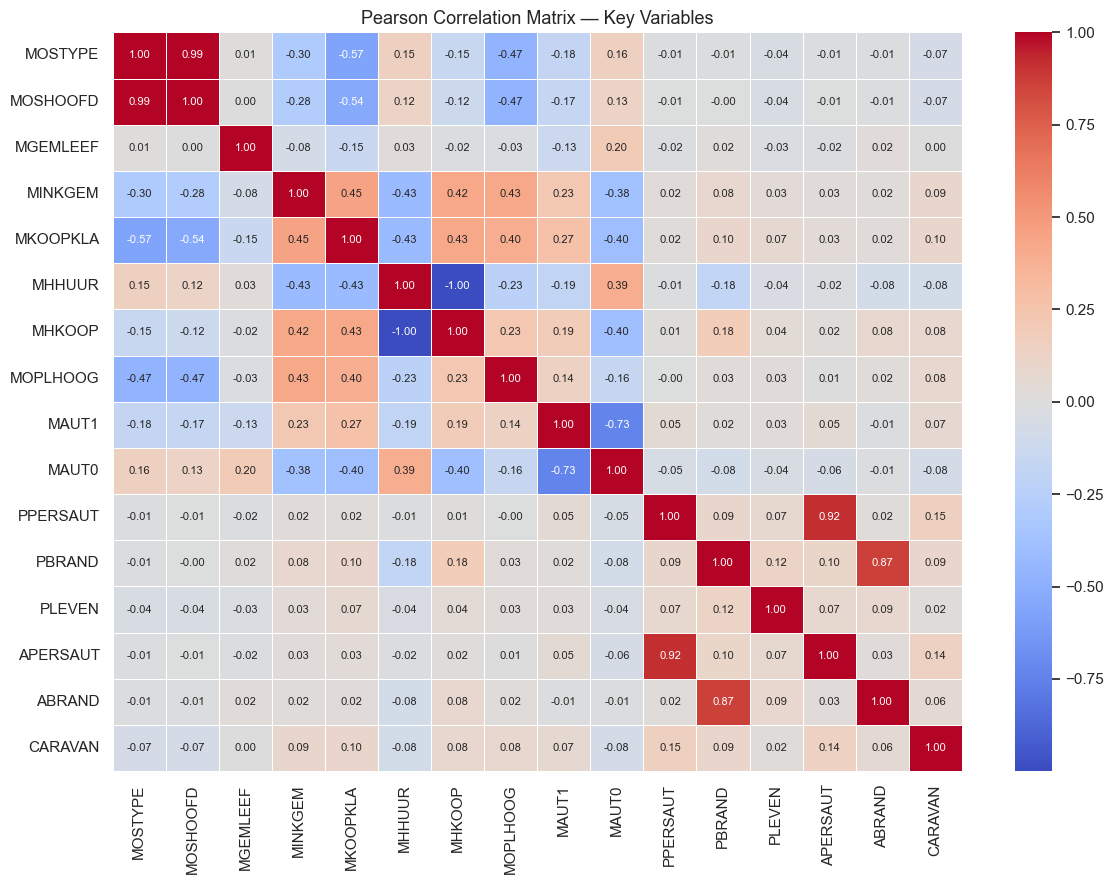

In [30]:
# Visualization 1: Pearson Correlation Heatmap
# Re-displayed here to support the data storytelling narrative
# This heatmap illustrates the two-world structure of the dataset —
# sociodemographic variables correlate within their group, and product variables
# correlate within theirs, but the two groups show almost no cross correlation

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Pearson Correlation Matrix — Key Variables', fontsize=13)
plt.tight_layout()
plt.show()

### Finding the Signal Through Clustering

The K-Means clustering analysis in Task 6 confirmed this intuition. When customers were 
grouped based on their combined demographic and product profiles, four distinct segments 
emerged. The PCA visualization shows these clusters occupying different regions of the 
reduced feature space, with Cluster 1 standing apart as a small but highly distinctive 
group of 344 customers.

Cluster 1 is the key finding of this project. Every single customer in this cluster owns 
a mobile home policy (CARAVAN = 1.000). They are characterized by the highest purchasing 
power (MKOOPKLA = 5.04), above average income (MINKGEM = 4.28), high car insurance 
contributions (PPERSAUT = 4.74), and moderate education levels. They are homeowners living 
in zip codes with relatively high car ownership rates.

 In contrast, Cluster 3, lower 
income renters with the lowest purchasing power, shows near zero mobile home policy 
ownership (CARAVAN = 0.002), and Cluster 2, the most affluent and educated segment, 
also shows zero ownership; suggesting that mobile home policies appeal to a specific 
middle-to-upper income bracket rather than the wealthiest customers.

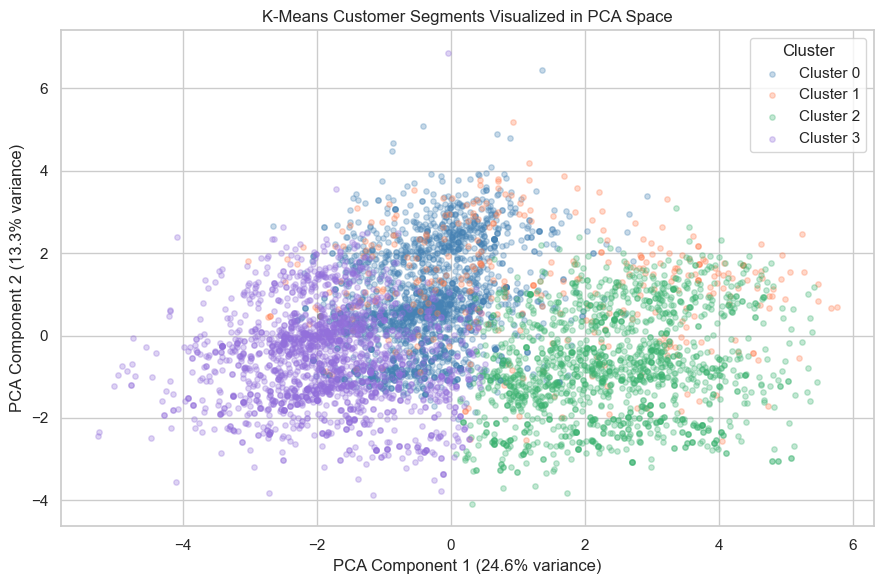

In [31]:
# Visualization 2: K-Means Clusters in PCA Space
# Re-displayed here to support the data storytelling narrative
# Cluster 1 (coral) represents the high-value mobile home policy owner segment
# that stands apart from the other three customer groups

plt.figure(figsize=(9, 6))

for i in range(k):
    mask = cluster_labels == i
    plt.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                alpha=0.3, s=15, color=colors[i], label=f'Cluster {i}')

plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-Means Customer Segments Visualized in PCA Space')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

### Modeling Performance and Limitations

The hypothesis testing in Task 4 confirmed that income differences between CARAVAN owners 
and non-owners are statistically significant (t = 6.994, p ≈ 0), and that car ownership 
rates in a customer's zip code are significantly associated with mobile home policy 
ownership (chi-squared = 36.99, p ≈ 0). However, translating these signals into a 
reliable predictive, only 6% of 
customers own a mobile home policy.

Logistic regression outperformed Random Forest on this task, achieving a ROC-AUC of 0.757 
compared to 0.671. The logistic regression correctly identified 72% of actual policy owners 
at the cost of a high false positive rate, which in a real marketing context is an 
acceptable tradeoff, it is better to contact 400 potential buyers and find 58 real ones 
than to miss them entirely. The Random Forest achieved higher overall accuracy but failed 
to capture the minority class meaningfully, a common pitfall when optimizing for accuracy 
on imbalan